In [1]:
import numpy as np
import pandas as pd
from packaging import version

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Dropout, Flatten, Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as k

In [2]:
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)

### Helper Functions

In [3]:
def get_three_classes(x, y):
    def indices_of(class_id):
        indices, _ = np.where(y == float(class_id))
        return indices

    indices = np.concatenate([indices_of(0), indices_of(1), indices_of(2)], axis=0)

    x = x[indices]
    y = y[indices]

    count = x.shape[0]
    indices = np.random.choice(range(count), count, replace=False)

    x = x[indices]
    y = y[indices]

    y = tf.keras.utils.to_categorical(y)

    return x, y

In [4]:
def show_random_examples(x, y, p):
    indices = np.random.choice(range(x.shape[0]), 10, replace=False)

    x = x[indices]
    y = y[indices]
    p = p[indices]

    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x[i])
        plt.xticks([])
        plt.yticks([])
        col = 'green' if np.argmax(y[i]) == np.argmax(p[i]) else 'red'
        plt.xlabel(class_names_preview[np.argmax(p[i])], color=col)
    plt.show()

In [5]:
def plot_history(history):
  losses = history.history['loss']
  accs = history.history['accuracy']
  val_losses = history.history['val_loss']
  val_accs = history.history['val_accuracy']
  epochs = len(losses)

  plt.figure(figsize=(16, 4))
  for i, metrics in enumerate(zip([losses, accs], [val_losses, val_accs], ['Loss', 'Accuracy'])):
    plt.subplot(1, 2, i + 1)
    plt.plot(range(epochs), metrics[0], label='Training {}'.format(metrics[2]))
    plt.plot(range(epochs), metrics[1], label='Validation {}'.format(metrics[2]))
    plt.legend()
  plt.show()

def display_training_curves(training, validation, title, subplot):
  ax = plt.subplot(subplot)
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['training', 'validation'])

In [6]:
def print_validation_report(y_test, predictions):
    print("Classification Report")
    print(classification_report(y_test, predictions))
    print('Accuracy Score: {}'.format(accuracy_score(y_test, predictions)))
    print('Root Mean Square Error: {}'.format(np.sqrt(MSE(y_test, predictions))))

In [7]:
def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(16,12))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.75,  cbar=False, ax=ax,cmap='Blues',linecolor='white')
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

### EDA

In [ ]:
#Look at shapes and structures
print('train_images:\t{}'.format(x_train.shape))
print('train_labels:\t{}'.format(y_train.shape))
print('test_images:\t\t{}'.format(x_test.shape))
print('test_labels:\t\t{}'.format(y_test.shape))

train_images:	(50000, 32, 32, 3)
train_labels:	(50000, 1)
test_images:		(10000, 32, 32, 3)
test_labels:		(10000, 1)


In [11]:
#Review Labels
print("First ten labels training dataset:\n {}\n".format(y_train[0:10]))
print("This output the numeric label, need to convert to item description")

First ten labels training dataset:
 [[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]

This output the numeric label, need to convert to item description


In [12]:
#Plot Subset of Examples
(train_images, train_labels),(test_images, test_labels)= tf.keras.datasets.cifar10.load_data()

In [13]:
x_preview, y_preview = get_three_classes(train_images, train_labels)
x_preview, y_preview = get_three_classes(test_images, test_labels)

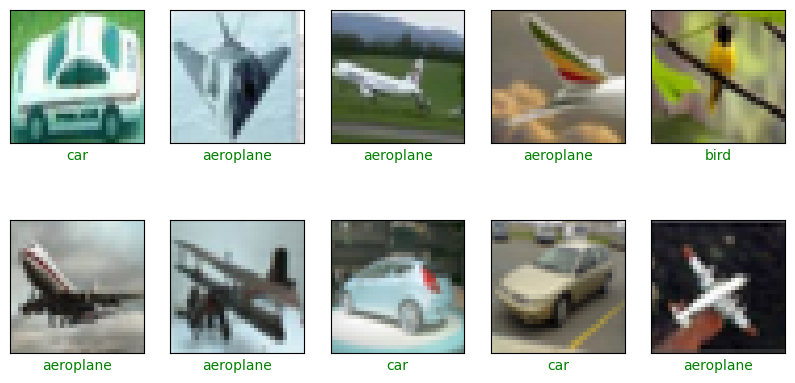

In [14]:
class_names_preview = ['aeroplane', 'car', 'bird']

show_random_examples(x_preview, y_preview, y_preview)

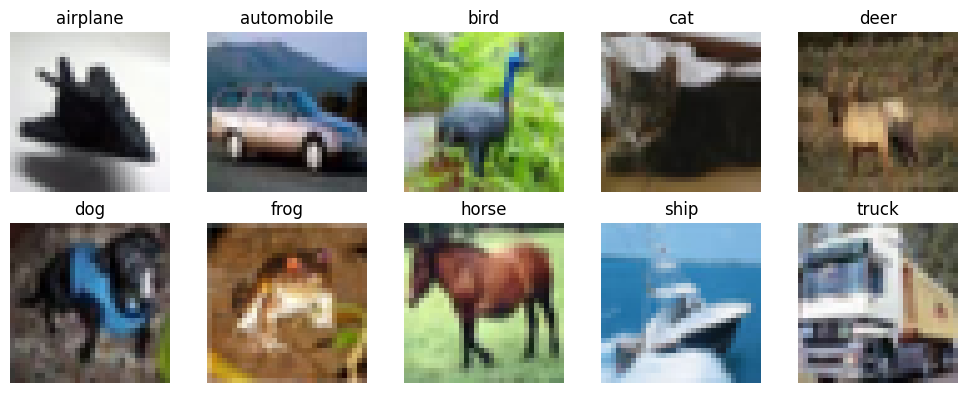

In [15]:
#Full grid of all 10 classes
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# pick one image per class
plt.figure(figsize=(10,4))
for i in range(10):
    idx = np.where(y_train.flatten() == i)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[idx])
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

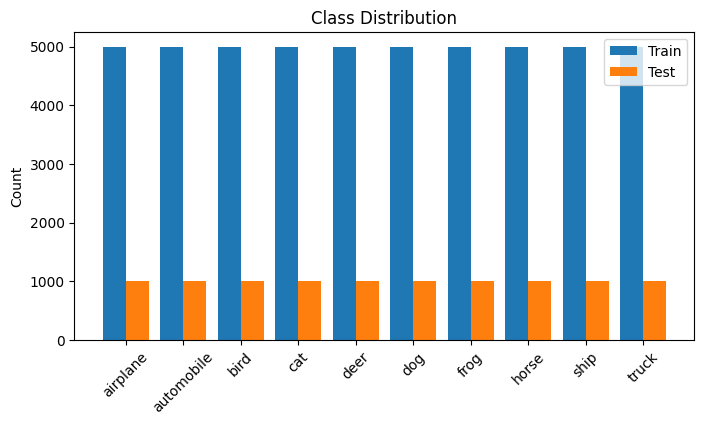

In [16]:
#Class distribution
train_counts = np.bincount(y_train.flatten())
test_counts  = np.bincount(y_test.flatten())

x = np.arange(10)

plt.figure(figsize=(8,4))
plt.bar(x - 0.2, train_counts, width=0.4, label='Train')
plt.bar(x + 0.2, test_counts,  width=0.4, label='Test')

plt.xticks(x, class_names, rotation=45)
plt.ylabel("Count")
plt.title("Class Distribution")
plt.legend()
plt.show()

### Data Preprocessing

In [17]:
class_names = ['airplane'
,'automobile'
,'bird'
,'cat'
,'deer'
,'dog'
,'frog'
,'horse'
,'ship'
,'truck']

In [18]:

#Validation Set
x_train_split, x_valid_split, y_train_split, y_valid_split = train_test_split(x_train                                            
                                                                              ,y_train
                                                                              ,test_size=.1
                                                                              ,random_state=42
                                                                              ,shuffle=True)

In [19]:
#Shape of train, validation, test sets
print(x_train_split.shape, x_valid_split.shape, x_test.shape)

(45000, 32, 32, 3) (5000, 32, 32, 3) (10000, 32, 32, 3)


In [20]:
#Rescale 
x_train_norm = x_train_split/255
x_valid_norm = x_valid_split/255
x_test_norm = x_test/255

### Design of Experiments

In [23]:
#Experiment Baseline Deep Neural Net (2 layers)

model1 = Sequential([
  Input(shape=x_train_norm.shape[1:]),
  Flatten(),
  Dense(512, activation='relu'),
  Dense(256, activation='relu'),
  Dense(10, activation='softmax')
])

model1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
import time

# --- TRAIN ---
start = time.time()

history1 = model1.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp1_dnn2.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time1 = time.time() - start

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3242 - loss: 1.8905 - val_accuracy: 0.3832 - val_loss: 1.7271
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3965 - loss: 1.6836 - val_accuracy: 0.3994 - val_loss: 1.6556
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4312 - loss: 1.5966 - val_accuracy: 0.3970 - val_loss: 1.7328
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4522 - loss: 1.5407 - val_accuracy: 0.4350 - val_loss: 1.5917
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4629 - loss: 1.5014 - val_accuracy: 0.4534 - val_loss: 1.5389
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4782 - loss: 1.4698 - val_accuracy: 0.4184 - val_loss: 1.6139
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4846 - loss: 1.4429 - val_accuracy: 0.4540 - val_loss: 1.5196
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4956 - loss: 1

In [28]:
#Results list
results = []

In [26]:
train_acc1 = max(history1.history['accuracy'])
val_acc1 = max(history1.history['val_accuracy'])

train_loss1 = min(history1.history['loss'])
val_loss1 = min(history1.history['val_loss'])

In [27]:
test_loss1, test_acc1 = model1.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4912 - loss: 1.4649


In [28]:
results.append({
    "Model": "DNN 2 Layer",
    "Train Acc": train_acc1,
    "Val Acc": val_acc1,
    "Test Acc": test_acc1,
    "Train Loss": train_loss1,
    "Val Loss": val_loss1,
    "Test Loss": test_loss1,
    "Time (s)": train_time1
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|DNN 2 Layer | 0.56 | 0.50 | 0.49 | 1.22 | 1.44 | 1.46 | 245.78 |


In [30]:
#Experiment 2 - DNN 3 Layer
model2 = Sequential([
  Input(shape=x_train_norm.shape[1:]),
  Flatten(),
  Dense(1024, activation='relu'),
  Dense(512, activation='relu'),
  Dense(256, activation='relu'),
  Dense(10, activation='softmax')
])

model2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
start = time.time()

history2 = model2.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp2_dnn3.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time2 = time.time() - start

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.3105 - loss: 1.9029 - val_accuracy: 0.3774 - val_loss: 1.7327
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3898 - loss: 1.6894 - val_accuracy: 0.3956 - val_loss: 1.6685
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.4289 - loss: 1.5900 - val_accuracy: 0.4254 - val_loss: 1.5791
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.4521 - loss: 1.5313 - val_accuracy: 0.4324 - val_loss: 1.5565
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.4681 - loss: 1.4839 - val_accuracy: 0.4418 - val_loss: 1.5400
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.4807 - loss: 1.4491 - val_accuracy: 0.4302 - val_loss: 1.5685
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.4918 - loss: 1.4194 - val_accuracy: 0.4566 - val_loss: 1.5030
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.5053 - loss: 1

In [32]:
train_acc2 = max(history2.history['accuracy'])
val_acc2 = max(history2.history['val_accuracy'])

train_loss2 = min(history2.history['loss'])
val_loss2 = min(history2.history['val_loss'])

In [33]:
test_loss2, test_acc2 = model2.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5037 - loss: 1.4399


In [35]:
results.append({
    "Model": "DNN 3 Layer",
    "Train Acc": train_acc2,
    "Val Acc": val_acc2,
    "Test Acc": test_acc2,
    "Train Loss": train_loss2,
    "Val Loss": val_loss2,
    "Test Loss": test_loss2,
    "Time (s)": train_time2
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|DNN 3 Layer | 0.58 | 0.49 | 0.50 | 1.15 | 1.46 | 1.44 | 500.54 |

In [37]:
#Experiment 3 - CNN 2 Layers Convolutional and Pooling
model3 = Sequential([
  Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]), 
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  MaxPool2D((2, 2),strides=2),
  Flatten(),
  Dense(128,activation=tf.nn.relu), 
  Dense(10, activation=tf.nn.softmax)
])

model3.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
start = time.time()

history3 = model3.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp3_cnn.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time3 = time.time() - start

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4612 - loss: 1.4967 - val_accuracy: 0.5344 - val_loss: 1.2742
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.6043 - loss: 1.1242 - val_accuracy: 0.6230 - val_loss: 1.0734
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.6538 - loss: 0.9959 - val_accuracy: 0.6460 - val_loss: 1.0033
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.6863 - loss: 0.9034 - val_accuracy: 0.6622 - val_loss: 0.9575
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.7133 - loss: 0.8302 - val_accuracy: 0.6804 - val_loss: 0.9188
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.7355 - loss: 0.7639 - val_accuracy: 0.6754 - val_loss: 0.9225
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.7570 - loss: 0.6993 - val_accuracy: 0.6898 - val_loss: 0.8978
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.7769 - loss: 0

In [39]:
train_acc3 = max(history3.history['accuracy'])
val_acc3 = max(history3.history['val_accuracy'])

train_loss3 = min(history3.history['loss'])
val_loss3 = min(history3.history['val_loss'])

In [40]:
test_loss3, test_acc3 = model3.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6800 - loss: 1.2015


In [41]:
results.append({
    "Model": "CNN 2 convolution/max pooling layers",
    "Train Acc": train_acc3,
    "Val Acc": val_acc3,
    "Test Acc": test_acc3,
    "Train Loss": train_loss3,
    "Val Loss": val_loss3,
    "Test Loss": test_loss3,
    "Time (s)": train_time3
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|CNN 2 convolution/max pooling layers | 0.88 | 0.70 | 0.68 | 0.34 | 0.89 | 1.20 | 524.46 |

In [43]:
#Experiment 4 - CNN 3 Layers Convolutional and Pooling
model4 = Sequential([
  Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]), 
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  MaxPool2D((2, 2),strides=2),
  Flatten(),
  Dense(128,activation=tf.nn.relu), 
  Dense(10, activation=tf.nn.softmax)
])

model4.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
start = time.time()

history4 = model4.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp4_cnn.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time4 = time.time() - start

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.4251 - loss: 1.5738 - val_accuracy: 0.5458 - val_loss: 1.2618
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.5740 - loss: 1.1992 - val_accuracy: 0.6056 - val_loss: 1.1021
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.6395 - loss: 1.0329 - val_accuracy: 0.6322 - val_loss: 1.0393
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.6737 - loss: 0.9299 - val_accuracy: 0.6592 - val_loss: 0.9751
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.7008 - loss: 0.8493 - val_accuracy: 0.6858 - val_loss: 0.8932
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.7331 - loss: 0.7724 - val_accuracy: 0.7056 - val_loss: 0.8459
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.7518 - loss: 0.7156 - val_accuracy: 0.6986 - val_loss: 0.8772
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.7696 - loss: 0

In [45]:
train_acc4 = max(history4.history['accuracy'])
val_acc4 = max(history4.history['val_accuracy'])

train_loss4 = min(history4.history['loss'])
val_loss4 = min(history4.history['val_loss'])

In [46]:
test_loss4, test_acc4 = model4.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7123 - loss: 0.9113


In [47]:
results.append({
    "Model": "CNN 3 convolution/max pooling layers",
    "Train Acc": train_acc4,
    "Val Acc": val_acc4,
    "Test Acc": test_acc4,
    "Train Loss": train_loss4,
    "Val Loss": val_loss4,
    "Test Loss": test_loss4,
    "Time (s)": train_time4
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|CNN 3 convolution/max pooling layers | 0.82 | 0.71 | 0.71 | 0.50 | 0.85 | 0.91 | 462.57 |

In [22]:
#Experiment 5 - CNN 3 layer (Smaller CNN)
model5 = Sequential([
  Conv2D(filters=16, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]), 
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  MaxPool2D((2, 2),strides=2),
  Flatten(),
  Dense(64,activation=tf.nn.relu),
  Dense(10, activation=tf.nn.softmax)
])

model5.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model5.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,530 (310.66 KB)

 Trainable params: 79,530 (310.66 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
start = time.time()

history5 = model5.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp5_cnn_smaller.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time5 = time.time() - start

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4162 - loss: 1.6056 - val_accuracy: 0.4892 - val_loss: 1.4269
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5378 - loss: 1.3028 - val_accuracy: 0.5436 - val_loss: 1.2843
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.5847 - loss: 1.1767 - val_accuracy: 0.5980 - val_loss: 1.1551
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.6190 - loss: 1.0886 - val_accuracy: 0.6142 - val_loss: 1.0882
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6421 - loss: 1.0242 - val_accuracy: 0.6124 - val_loss: 1.0854
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.6598 - loss: 0.9728 - val_accuracy: 0.6210 - val_loss: 1.0700
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6764 - loss: 0.9339 - val_accuracy: 0.6500 - val_loss: 1.0030
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6890 - loss: 0

In [25]:
train_acc5 = max(history5.history['accuracy'])
val_acc5 = max(history5.history['val_accuracy'])

train_loss5 = min(history5.history['loss'])
val_loss5 = min(history5.history['val_loss'])

In [26]:
test_loss5, test_acc5 = model5.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6710 - loss: 0.9752


In [29]:
results.append({
    "Model": "CNN 3 layer (smaller)",
    "Train Acc": train_acc5,
    "Val Acc": val_acc5,
    "Test Acc": test_acc5,
    "Train Loss": train_loss5,
    "Val Loss": val_loss5,
    "Test Loss": test_loss5,
    "Time (s)": train_time5
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|CNN 3 (smaller neurons) | 0.74 | 0.66 | 0.67 | 0.74 | 0.94 | 0.98 | 268.83 |

In [31]:
#Experiment 6 - CNN 2 layer + Dropout (0.5)
model6 = Sequential([
  Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]), 
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  MaxPool2D((2, 2),strides=2),
  Flatten(),
  Dense(128,activation=tf.nn.relu),
  Dropout(0.5), 
  Dense(10, activation=tf.nn.softmax)
])

model6.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model6.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
start = time.time()

history6 = model6.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp6_cnn_dropout.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time6 = time.time() - start

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.3996 - loss: 1.6466 - val_accuracy: 0.5300 - val_loss: 1.3256
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5209 - loss: 1.3390 - val_accuracy: 0.5792 - val_loss: 1.1964
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.5760 - loss: 1.2121 - val_accuracy: 0.6172 - val_loss: 1.0913
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.6056 - loss: 1.1248 - val_accuracy: 0.6446 - val_loss: 1.0206
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.6308 - loss: 1.0566 - val_accuracy: 0.6556 - val_loss: 0.9777
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.6477 - loss: 1.0047 - val_accuracy: 0.6632 - val_loss: 0.9515
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.6640 - loss: 0.9536 - val_accuracy: 0.6782 - val_loss: 0.9103
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.6789 - loss: 0

In [33]:
train_acc6 = max(history6.history['accuracy'])
val_acc6 = max(history6.history['val_accuracy'])

train_loss6 = min(history6.history['loss'])
val_loss6 = min(history6.history['val_loss'])

In [34]:
test_loss6, test_acc6 = model6.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7107 - loss: 0.8739


In [35]:
results.append({
    "Model": "CNN 2 layer + dropout",
    "Train Acc": train_acc6,
    "Val Acc": val_acc6,
    "Test Acc": test_acc6,
    "Train Loss": train_loss6,
    "Val Loss": val_loss6,
    "Test Loss": test_loss6,
    "Time (s)": train_time6
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|CNN 2 layer + dropout | 0.76 | 0.71 | 0.71 | 0.67 | 0.85 | 0.87 | 635.49 |

In [37]:
#Experiment 7 - CNN 2 layer + Batch Normalization
model7 = Sequential([
  Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]),
  BatchNormalization(), 
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  BatchNormalization(),
  MaxPool2D((2, 2),strides=2),
  Flatten(),
  Dense(128,activation=tf.nn.relu),
  Dense(10, activation=tf.nn.softmax)
])

model7.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model7.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [38]:
start = time.time()

history7 = model7.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp7_cnn_batch.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time7 = time.time() - start

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 58ms/step - accuracy: 0.5343 - loss: 1.3239 - val_accuracy: 0.5656 - val_loss: 1.2594
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6742 - loss: 0.9305 - val_accuracy: 0.5908 - val_loss: 1.2070
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7375 - loss: 0.7493 - val_accuracy: 0.6266 - val_loss: 1.0682
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7865 - loss: 0.6120 - val_accuracy: 0.5894 - val_loss: 1.3381
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.8303 - loss: 0.4841 - val_accuracy: 0.6846 - val_loss: 1.0155
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.8708 - loss: 0.3701 - val_accuracy: 0.6674 - val_loss: 1.0976
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.9055 - loss: 0.2773 - val_accuracy: 0.6928 - val_loss: 1.1664
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9255 - loss: 0

In [39]:
train_acc7 = max(history7.history['accuracy'])
val_acc7 = max(history7.history['val_accuracy'])

train_loss7 = min(history7.history['loss'])
val_loss7 = min(history7.history['val_loss'])

In [40]:
test_loss7, test_acc7 = model7.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6702 - loss: 1.7134


In [41]:
results.append({
    "Model": "CNN 2 layer + batch normalization",
    "Train Acc": train_acc7,
    "Val Acc": val_acc7,
    "Test Acc": test_acc7,
    "Train Loss": train_loss7,
    "Val Loss": val_loss7,
    "Test Loss": test_loss7,
    "Time (s)": train_time7
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|CNN 2 layer + batch normalization | 0.95 | 0.69 | 0.67 | 0.14 | 1.02 | 1.71 | 409.28 |

In [43]:
#Experiment 8 - CNN 2 layer + Dropout + Batch Normalization
model8 = Sequential([
  Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]),
  BatchNormalization(), 
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  BatchNormalization(),
  MaxPool2D((2, 2),strides=2),
  Flatten(),
  Dense(128,activation=tf.nn.relu),
  Dropout(0.3),
  Dense(10, activation=tf.nn.softmax)
])

model8.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model8.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [44]:
start = time.time()

history8 = model8.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp8_cnn_dropoout&batch.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time8 = time.time() - start

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.4618 - loss: 1.5159 - val_accuracy: 0.4652 - val_loss: 1.6559
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.5968 - loss: 1.1433 - val_accuracy: 0.5766 - val_loss: 1.2529
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6638 - loss: 0.9643 - val_accuracy: 0.6512 - val_loss: 0.9696
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.6999 - loss: 0.8480 - val_accuracy: 0.6498 - val_loss: 0.9933
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7325 - loss: 0.7587 - val_accuracy: 0.6712 - val_loss: 0.9718
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7625 - loss: 0.6770 - val_accuracy: 0.6824 - val_loss: 0.9583
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7816 - loss: 0.6185 - val_accuracy: 0.6870 - val_loss: 0.9166
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.8008 - loss: 0

In [45]:
train_acc8 = max(history8.history['accuracy'])
val_acc8 = max(history8.history['val_accuracy'])

train_loss8 = min(history8.history['loss'])
val_loss8 = min(history8.history['val_loss'])

In [46]:
test_loss8, test_acc8 = model8.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6905 - loss: 1.1084


In [47]:
results.append({
    "Model": "CNN 2 layer + dropout + batch normalization",
    "Train Acc": train_acc8,
    "Val Acc": val_acc8,
    "Test Acc": test_acc8,
    "Train Loss": train_loss8,
    "Val Loss": val_loss8,
    "Test Loss": test_loss8,
    "Time (s)": train_time8
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|CNN 2 layer + dropout + batch normalization | 0.89 | 0.72 | 0.69 | 0.29 | 0.92 | 1.11 | 736.74 |

In [55]:
#Experiment 9 - CNN 3 layer + Dropout + Batch Normalization
model9 = Sequential([
  Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]),
  BatchNormalization(), 
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  BatchNormalization(),
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  BatchNormalization(),
  MaxPool2D((2,2)),
  Flatten(),
  Dense(128,activation=tf.nn.relu),
  Dropout(0.3),
  Dense(10, activation=tf.nn.softmax)
])

model9.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model9.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
start = time.time()

history9 = model9.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp9_cnn_dropoout&batch2.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time9 = time.time() - start

In [51]:
train_acc9 = max(history9.history['accuracy'])
val_acc9 = max(history9.history['val_accuracy'])

train_loss9 = min(history9.history['loss'])
val_loss9 = min(history9.history['val_loss'])

In [52]:
test_loss9, test_acc9 = model9.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6459 - loss: 1.5327


In [53]:
results.append({
    "Model": "CNN 3 layer + dropout + batch normalization",
    "Train Acc": train_acc9,
    "Val Acc": val_acc9,
    "Test Acc": test_acc9,
    "Train Loss": train_loss9,
    "Val Loss": val_loss9,
    "Test Loss": test_loss9,
    "Time (s)": train_time9
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|CNN 3 layer + dropout + batch normalization | 0.87 | 0.73 | 0.72 | 0.36 | 0.87 | 1.01 | 500.41 |

In [ ]:
#Experiment 10 - CNN 3 layer + Dropout + Batch Normalization + Slower Learning Rate
model10 = Sequential([
  Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]),
  BatchNormalization(), 
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  BatchNormalization(),
  MaxPool2D((2, 2),strides=2),
  Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),
  BatchNormalization(),
  MaxPool2D((2,2)),
  Flatten(),
  Dense(128,activation=tf.nn.relu),
  Dropout(0.3),
  Dense(10, activation=tf.nn.softmax)
])

model10.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model10.summary()

In [ ]:
start = time.time()

history10 = model10.fit(x_train_norm
                    ,y_train_split
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(x_valid_norm, y_valid_split)
                    ,callbacks=[
                     tf.keras.callbacks.ModelCheckpoint("exp10_cnn_dropoout&batch3.keras",save_best_only=True,save_weights_only=False)
                     ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
                    ]
                   )

train_time10 = time.time() - start

In [ ]:
train_acc10 = max(history10.history['accuracy'])
val_acc10 = max(history10.history['val_accuracy'])

train_loss10 = min(history10.history['loss'])
val_loss10 = min(history10.history['val_loss'])

In [ ]:
test_loss10, test_acc10 = model10.evaluate(x_test_norm, y_test)

In [ ]:
results.append({
    "Model": "CNN 3 layer + dropout + batch normalization + slower learning rate",
    "Train Acc": train_acc10,
    "Val Acc": val_acc10,
    "Test Acc": test_acc10,
    "Train Loss": train_loss10,
    "Val Loss": val_loss10,
    "Test Loss": test_loss10,
    "Time (s)": train_time10
})

| Model | Train Acc | Val ACC | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|-------|-------|-----------|----------|------------|----------|-----------|----------|
|CNN 3 layer + dropout + batch normalization + slower learning rate | 0.86 | 0.71 | 0.70 | 0.38 | 0.89 | 1.03 | 642.30 |

| Model | Train Acc | Val Acc | Test Acc | Train Loss | Val Loss | Test Loss | Time (s) |
|---|---|---|---|---|---|---|---|
| DNN 2 Layer | 0.56 | 0.50 | 0.49 | 1.22 | 1.44 | 1.46 | 245.78 |
| DNN 3 Layer | 0.58 | 0.49 | 0.50 | 1.15 | 1.46 | 1.44 | 500.54 |
| CNN 2 Convolution/MaxPooling Layers | 0.88 | 0.70 | 0.68 | 0.34 | 0.89 | 1.20 | 524.46 |
| CNN 3 Convolution/MaxPooling Layers | 0.82 | 0.71 | 0.71 | 0.50 | 0.85 | 0.91 | 462.57 |
| CNN 3 (Smaller Neurons) | 0.74 | 0.66 | 0.67 | 0.74 | 0.94 | 0.98 | 268.83 |
| CNN 2 Layer + Dropout | 0.76 | 0.71 | 0.71 | 0.67 | 0.85 | 0.87 | 635.49 |
| CNN 2 Layer + Batch Normalization | 0.95 | 0.69 | 0.67 | 0.14 | 1.02 | 1.71 | 409.28 |
| CNN 2 Layer + Dropout + Batch Normalization | 0.89 | 0.72 | 0.69 | 0.29 | 0.92 | 1.11 | 736.74 |
| CNN 3 Layer + Dropout + Batch Normalization | 0.87 | 0.73 | 0.72 | 0.36 | 0.87 | 1.01 | 500.41 |
| CNN 3 Layer + Dropout + Batch Normalization + Slower Learning Rate | 0.86 | 0.71 | 0.70 | 0.38 | 0.89 | 1.03 | 642.30 |

In [ ]:
#Visualize Feature Maps
#Use experiment 9

test_images = x_test
test_labels = y_test

img = test_images[2004]

# Normalize
img = img.astype("float32") / 255.0

# Convert to batch format
img_tensor = np.expand_dims(img, axis=0)

class_names = ['airplane'
,'automobile'
,'bird'
,'cat'
,'deer'
,'dog'
,'frog'
,'horse'
,'ship'
,'truck']

plt.imshow(img, cmap='viridis')
plt.axis('off')
plt.show()

In [ ]:
# Extracts the outputs of the top 8 layers:
layer_outputs = [layer.output for layer in model9.layers[:8]]
# Creates a model that will return these outputs, given the model input:
activation_model = models.Model(inputs=model9.inputs, outputs=layer_outputs)

In [ ]:
activations = activation_model.predict(img_tensor)
len(activations)

In [ ]:
layer_names = []
for layer in model9.layers:
    layer_names.append(layer.name)

layer_names

In [ ]:
# These are the names of the layers, so can have them as part of our plot
layer_names = []
for layer in model9.layers[:3]:
    layer_names.append(layer.name)

images_per_row = 16

# Now let's display our feature maps
for layer_name, layer_activation in zip(layer_names, activations):
    # This is the number of features in the feature map
    n_features = layer_activation.shape[-1]

    # The feature map has shape (1, size, size, n_features)
    size = layer_activation.shape[1]

    # We will tile the activation channels in this matrix
    n_cols = n_features // images_per_row
    display_grid = np.zeros((size * n_cols, images_per_row * size))

    # We'll tile each filter into this big horizontal grid
    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_activation[0,
                                             :, :,
                                             col * images_per_row + row]
            # Post-process the feature to make it visually palatable
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * size : (col + 1) * size,
                         row * size : (row + 1) * size] = channel_image

    # Display the grid
    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

plt.show();